In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import os

# Configure logging if you haven't already
# logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Define the filename (adjust path if needed)
# Assuming it's in ../data/EOS/ relative to where the notebook is run
# Adjust the base path logic as needed for your structure
try:
    # A simple relative path - adjust if your notebook isn't in the 'notebooks' dir
    base_path = "./"
    filename = os.path.join(base_path, "aneosRock.dat")
    if not os.path.exists(filename):
         # Fallback if run from a different structure
         base_path = "./data/EOS/" # Example: if run from project root
         filename = os.path.join(base_path, "aneosRock.dat")
         if not os.path.exists(filename):
              raise FileNotFoundError("Cannot find aneosRock.dat in expected locations.")

except FileNotFoundError as e:
    print(f"ERROR: {e}")
    # Stop execution or handle appropriately
    raise

# --- Infer Column Meanings and Units (Hypothesis based on ANEOS & previous context) ---
# Col 1: Temperature (K)
# Col 2: Density (g/cm³)
# Col 3: Pressure (bar) - Requires verification
# Col 4: Internal Energy (MJ/kg) - Requires verification
# Col 5: Entropy (MJ/kg/K) - Requires verification
column_names = ['Temperature_K', 'Density_g_cm3', 'Pressure_bar', 'InternalEnergy_MJ_kg', 'Entropy_MJ_kgK']

# --- Load the data ---
try:
    # Read the file, letting pandas INFER column widths based on whitespace
    # Using sep='\s+' to handle one or more spaces as delimiter
    df_rock = pd.read_csv(filename, sep='\s+', header=None, names=column_names,
                          comment='#', # Assuming lines starting with # are comments
                          engine='python') # Use python engine for regex separator

    print(f"Successfully read {len(df_rock)} rows from {filename}.")
    print(f"  Detected {len(df_rock.columns)} columns.")

    if len(df_rock.columns) != len(column_names):
        print(f"[ERROR] Read {len(df_rock.columns)} columns, but expected {len(column_names)} based on names.")
        print("  Check the file format and separator.")
        # Set df_rock to None to prevent further errors
        df_rock = None
    else:
        # --- Convert columns to numeric ---
        print("\nConverting columns to numeric type...")
        conversion_errors = False
        for col in column_names:
            df_rock[col] = pd.to_numeric(df_rock[col], errors='coerce')
            if df_rock[col].isnull().any():
                print(f"  [WARN] Column '{col}' contained non-numeric values (NaN).")
                conversion_errors = True
        if conversion_errors:
             print("  Please check the original data file for non-numeric entries.")

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
    df_rock = None
except Exception as e:
    print(f"An error occurred while loading/processing the rock EOS file: {e}")
    df_rock = None

# Display basic info and head if loaded successfully
if df_rock is not None:
    print("\nDataFrame Info:")
    df_rock.info()
    print("\nFirst 5 rows:")
    print(df_rock.head())
else:
    print("\nCould not load or process rock EOS data.")

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_452773/261233002.py:41: SyntaxWarning: invalid escape sequence '\s'
  df_rock = pd.read_csv(filename, sep='\s+', header=None, names=column_names,


Successfully read 25050 rows from ./aneosRock.dat.
  Detected 5 columns.

Converting columns to numeric type...

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25050 entries, 0 to 25049
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature_K         25050 non-null  float64
 1   Density_g_cm3         25050 non-null  float64
 2   Pressure_bar          25050 non-null  float64
 3   InternalEnergy_MJ_kg  25050 non-null  float64
 4   Entropy_MJ_kgK        25050 non-null  float64
dtypes: float64(5)
memory usage: 978.6 KB

First 5 rows:
   Temperature_K  Density_g_cm3  Pressure_bar  InternalEnergy_MJ_kg  \
0         1000.0            0.1      183.3040              3.122284   
1         1000.0            0.2      193.3709              2.831866   
2         1000.0            0.3      220.8221              2.629721   
3         1000.0            0.4      328.6690              2.4700

In [2]:
if df_rock is not None:
    print("\n--- Basic Checks & Statistics ---")

    # Check for NaN/Inf values introduced during loading/conversion
    nan_inf_check = df_rock.isnull().any().any() or np.isinf(df_rock.values).any()
    if nan_inf_check:
        print("[WARN] NaN or Inf values detected in the DataFrame after initial load.")
        print("Counts per column:")
        print("NaNs:\n", df_rock.isnull().sum())
        print("Infs:\n", df_rock.apply(lambda x: np.isinf(x).sum()))
        # Optionally drop them: df_rock = df_rock.replace([np.inf, -np.inf], np.nan).dropna()
    else:
        print("[PASS] No NaN or Inf values detected initially.")

    # Display descriptive statistics
    print("\nDescriptive Statistics:")
    # Format float display for better readability
    with pd.option_context('display.float_format', '{:.4g}'.format):
      print(df_rock.describe())

    # Check Positivity (where applicable)
    print("\nPositivity Checks:")
    all_positive = True
    for col in ['Temperature_K', 'Density_g_cm3', 'Pressure_bar']: # Add others if always positive
        if col in df_rock.columns:
            if (df_rock[col].dropna() <= 0).any():
                print(f"  [FAIL] Found non-positive values in column '{col}'.")
                all_positive = False
            else:
                print(f"  [PASS] Column '{col}' contains positive values.")
    if all_positive: print("Basic positivity checks passed.")

else:
    print("Skipping checks because DataFrame was not loaded.")


--- Basic Checks & Statistics ---
[PASS] No NaN or Inf values detected initially.

Descriptive Statistics:
       Temperature_K  Density_g_cm3  Pressure_bar  InternalEnergy_MJ_kg  \
count      2.505e+04      2.505e+04     2.505e+04             2.505e+04   
mean        2.55e+04           25.1     4.841e+08                  1202   
std        1.443e+04          14.46     4.306e+08                 780.9   
min             1000            0.1         183.3                 2.041   
25%          1.3e+04           12.6     8.783e+07                 480.8   
50%         2.55e+04           25.1     3.704e+08                  1172   
75%          3.8e+04           37.6     8.221e+08                  1885   
max            5e+04           50.1     1.449e+09                  2663   

       Entropy_MJ_kgK  
count       2.505e+04  
mean          0.01208  
std          0.003368  
min          0.003053  
25%           0.01047  
50%           0.01265  
75%            0.0141  
max           0.02324  



--- Plotting Relationships (Assuming T=1000K Isotherm) ---
Applying filters for plotting...
No points filtered for plotting.


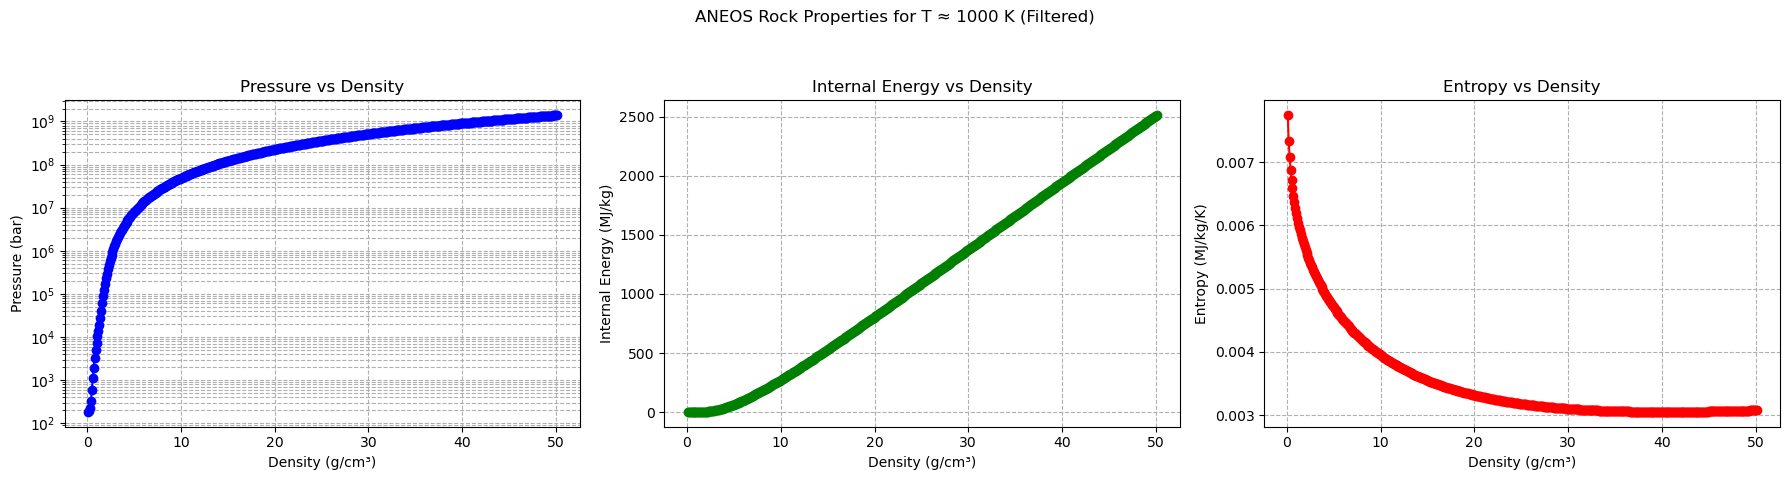

In [3]:
if df_rock is not None and not df_rock.empty:
    print("\n--- Plotting Relationships (Assuming T=1000K Isotherm) ---")

    # Filter for the specific temperature if multiple exist, otherwise assume single T
    unique_temps = df_rock['Temperature_K'].unique()
    if len(unique_temps) == 1:
        plot_data = df_rock
        plot_title_suffix = f" at T = {unique_temps[0]:.0f} K"
    elif 1000.0 in unique_temps:
         plot_data = df_rock[np.isclose(df_rock['Temperature_K'], 1000.0)].copy()
         plot_title_suffix = " for T ≈ 1000 K"
         if plot_data.empty:
              print("WARN: No data found for T=1000K, plotting all data.")
              plot_data = df_rock # Fallback to all data if filtering fails
              plot_title_suffix = "(All Temperatures)"
    else:
         plot_data = df_rock # Plot all data if 1000K isn't present
         plot_title_suffix = "(All Temperatures)"


    # --- Apply outlier filtering just for plotting ---
    print("Applying filters for plotting...")
    T_unfilt = plot_data['Temperature_K'] # Use actual T if multiple
    rho_unfilt = plot_data['Density_g_cm3']
    P_unfilt = plot_data['Pressure_bar']
    U_unfilt = plot_data['InternalEnergy_MJ_kg']
    S_unfilt = plot_data['Entropy_MJ_kgK']

    # Define bounds (adjust based on .describe() output if needed)
    T_min, T_max = 1e-1, 1e5  # K
    P_min, P_max = 1e-9, 1e10 # bar (Adjust max based on data)
    rho_min, rho_max = 1e-2, 1e2 # g/cm3 (Adjust based on data)
    U_min, U_max = -100, 1e4  # MJ/kg (Adjust based on data)
    S_min, S_max = -1, 1     # MJ/kg/K (Adjust based on data)

    mask = (
        (T_unfilt > T_min) & (T_unfilt < T_max) & (P_unfilt > P_min) & (P_unfilt < P_max) &
        (rho_unfilt > rho_min) & (rho_unfilt < rho_max) & (U_unfilt > U_min) & (U_unfilt < U_max) &
        (S_unfilt > S_min) & (S_unfilt < S_max) &
        (~np.isnan(T_unfilt)) & (~np.isinf(T_unfilt)) & (~np.isnan(P_unfilt)) & (~np.isinf(P_unfilt)) &
        (~np.isnan(rho_unfilt)) & (~np.isinf(rho_unfilt)) & (~np.isnan(U_unfilt)) & (~np.isinf(U_unfilt)) &
        (~np.isnan(S_unfilt)) & (~np.isinf(S_unfilt))
    )
    plot_data_filtered = plot_data[mask]
    filtered_count = len(plot_data) - len(plot_data_filtered)
    if filtered_count > 0: print(f"Filtered out {filtered_count} points for plotting.")
    else: print("No points filtered for plotting.")
    # ---------------------------------------------

    if plot_data_filtered.empty:
        print("No data left after filtering for plots.")
    else:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # P vs Rho
        axs[0].plot(plot_data_filtered['Density_g_cm3'], plot_data_filtered['Pressure_bar'], 'bo-')
        axs[0].set_xlabel("Density (g/cm³)")
        axs[0].set_ylabel("Pressure (bar)")
        axs[0].set_title("Pressure vs Density")
        axs[0].set_yscale('log') # Pressure often spans orders of magnitude
        axs[0].grid(True, which='both', linestyle='--')

        # U vs Rho
        axs[1].plot(plot_data_filtered['Density_g_cm3'], plot_data_filtered['InternalEnergy_MJ_kg'], 'go-')
        axs[1].set_xlabel("Density (g/cm³)")
        axs[1].set_ylabel("Internal Energy (MJ/kg)")
        axs[1].set_title("Internal Energy vs Density")
        axs[1].grid(True, which='both', linestyle='--')

        # S vs Rho
        axs[2].plot(plot_data_filtered['Density_g_cm3'], plot_data_filtered['Entropy_MJ_kgK'], 'ro-')
        axs[2].set_xlabel("Density (g/cm³)")
        axs[2].set_ylabel("Entropy (MJ/kg/K)")
        axs[2].set_title("Entropy vs Density")
        axs[2].grid(True, which='both', linestyle='--')
        # axs[2].set_ylim(bottom=0) # Optional: Set entropy lower limit if needed

        plt.suptitle(f"ANEOS Rock Properties{plot_title_suffix} (Filtered)")
        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        plt.show()

else:
    print("Skipping plots because DataFrame was not loaded.")


--- Plotting Multiple Rock EOS Isotherms ---
Found 50 unique temperatures in the rock data.
Plotting isotherms for T (K) approx: [ 1000.  8000. 15000. 22000. 29000. 36000. 43000. 50000.]


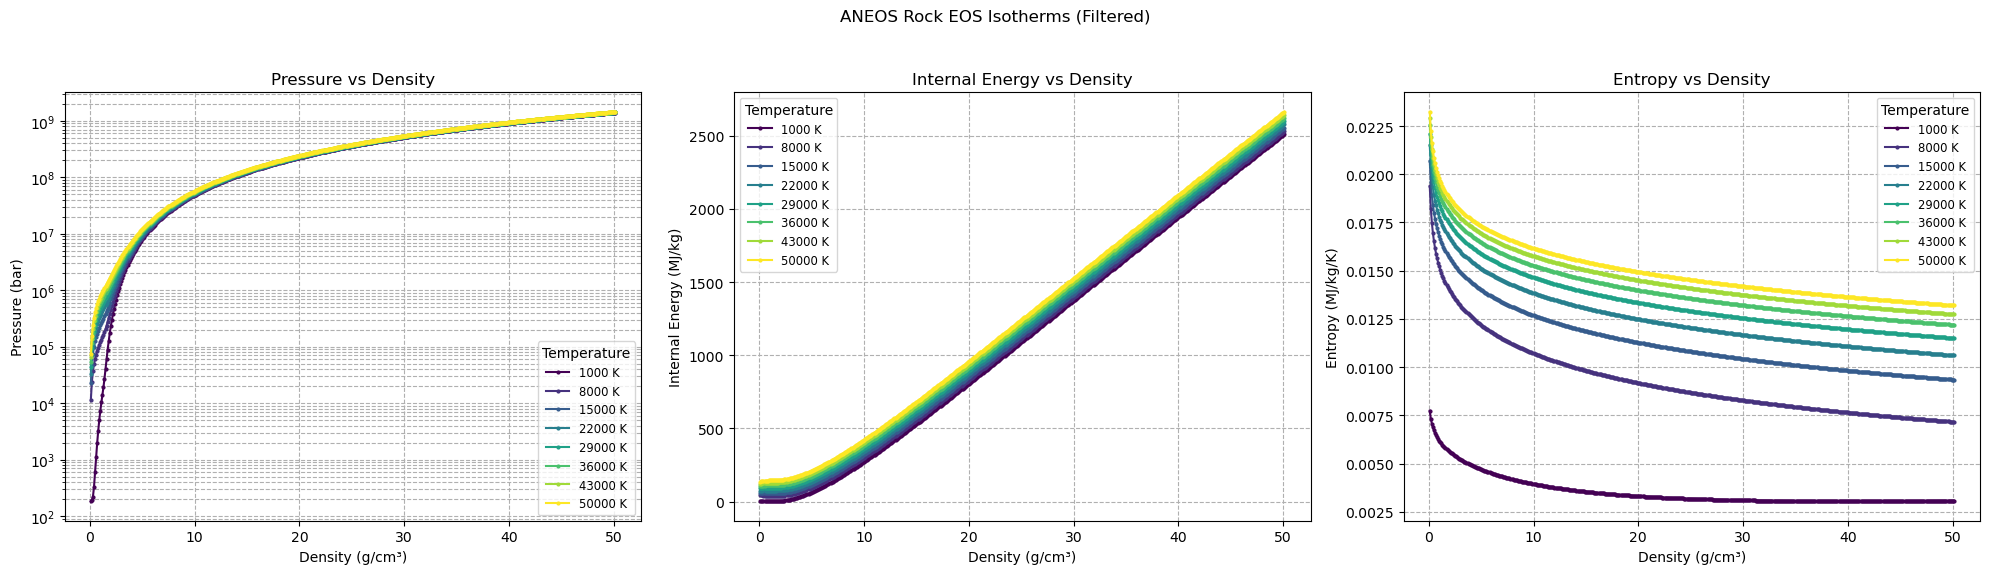

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

print("\n--- Plotting Multiple Rock EOS Isotherms ---")

# Ensure df_rock is loaded and valid from Cell 1
if 'df_rock' not in locals() or df_rock is None or df_rock.empty:
    print("ERROR: Rock EOS DataFrame ('df_rock') not loaded or empty. Please run Cell 1 first.")
else:
    # Identify unique temperatures
    unique_temps = sorted(df_rock['Temperature_K'].dropna().unique())
    print(f"Found {len(unique_temps)} unique temperatures in the rock data.")
    # print(f"Temperatures (K): {np.round(unique_temps, 0)}") # Optional: print temps

    # Select a subset of temperatures to plot (e.g., max 8)
    num_isotherms_to_plot = 8
    if len(unique_temps) > num_isotherms_to_plot:
        indices = np.linspace(0, len(unique_temps) - 1, num_isotherms_to_plot, dtype=int)
        temps_to_plot = [unique_temps[i] for i in indices]
    else:
        temps_to_plot = unique_temps

    print(f"Plotting isotherms for T (K) approx: {np.round(temps_to_plot, 0)}")

    # Define plausible physical bounds (same as before, adjust if needed)
    T_min, T_max = 1e-1, 1e8; P_min, P_max = 1e-9, 1e13
    rho_min, rho_max = 1e-9, 1e4; S_min, S_max = -50, 1000 # MJ/kg/K
    U_min, U_max = -100, 1e4 # MJ/kg - Adding bounds for energy column

    # Create plots
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) # Wider figure

    # Use a color map for different temperatures
    colors = plt.cm.viridis(np.linspace(0, 1, len(temps_to_plot)))

    plot_successful = False
    for i, temp in enumerate(temps_to_plot):
        # Select data for the current isotherm (use isclose for float comparison)
        isotherm_data = df_rock[np.isclose(df_rock['Temperature_K'], temp)].copy()

        if isotherm_data.empty:
            print(f"No data found for T={temp:.0f} K, skipping.")
            continue

        # Filter this specific isotherm
        T_filt = isotherm_data['Temperature_K']
        rho_filt = isotherm_data['Density_g_cm3']
        P_filt = isotherm_data['Pressure_bar']
        U_filt = isotherm_data['InternalEnergy_MJ_kg']
        S_filt = isotherm_data['Entropy_MJ_kgK']

        mask = (
            (T_filt > T_min) & (T_filt < T_max) & (P_filt > P_min) & (P_filt < P_max) &
            (rho_filt > rho_min) & (rho_filt < rho_max) & (U_filt > U_min) & (U_filt < U_max) &
            (S_filt > S_min) & (S_filt < S_max) &
            (~np.isnan(T_filt)) & (~np.isinf(T_filt)) & (~np.isnan(P_filt)) & (~np.isinf(P_filt)) &
            (~np.isnan(rho_filt)) & (~np.isinf(rho_filt)) & (~np.isnan(U_filt)) & (~np.isinf(U_filt)) &
            (~np.isnan(S_filt)) & (~np.isinf(S_filt))
        )
        isotherm_filtered = isotherm_data[mask]

        if isotherm_filtered.empty:
            print(f"No data left after filtering for T={temp:.0f} K, skipping plot for this temp.")
            continue

        plot_successful = True # Mark that at least one isotherm was plotted

        # Sort by density for cleaner lines
        isotherm_filtered = isotherm_filtered.sort_values(by='Density_g_cm3')

        label = f'{temp:.0f} K'
        color = colors[i]

        # P vs Rho
        axs[0].plot(isotherm_filtered['Density_g_cm3'], isotherm_filtered['Pressure_bar'],
                    marker='.', markersize=4, linestyle='-', color=color, label=label)
        # U vs Rho
        axs[1].plot(isotherm_filtered['Density_g_cm3'], isotherm_filtered['InternalEnergy_MJ_kg'],
                    marker='.', markersize=4, linestyle='-', color=color, label=label)
        # S vs Rho
        axs[2].plot(isotherm_filtered['Density_g_cm3'], isotherm_filtered['Entropy_MJ_kgK'],
                    marker='.', markersize=4, linestyle='-', color=color, label=label)

    if plot_successful:
        # Formatting P vs Rho plot
        axs[0].set_xlabel("Density (g/cm³)")
        axs[0].set_ylabel("Pressure (bar)")
        axs[0].set_title("Pressure vs Density")
        axs[0].set_yscale('log')
        axs[0].grid(True, which='both', linestyle='--')
        axs[0].legend(title="Temperature", fontsize='small')

        # Formatting U vs Rho plot
        axs[1].set_xlabel("Density (g/cm³)")
        axs[1].set_ylabel("Internal Energy (MJ/kg)")
        axs[1].set_title("Internal Energy vs Density")
        axs[1].grid(True, which='both', linestyle='--')
        axs[1].legend(title="Temperature", fontsize='small')

        # Formatting S vs Rho plot
        axs[2].set_xlabel("Density (g/cm³)")
        axs[2].set_ylabel("Entropy (MJ/kg/K)")
        axs[2].set_title("Entropy vs Density")
        axs[2].grid(True, which='both', linestyle='--')
        axs[2].legend(title="Temperature", fontsize='small')

        plt.suptitle("ANEOS Rock EOS Isotherms (Filtered)")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print("\nNo valid isotherms found to plot after filtering.")